In [80]:
import torch
import cv2

print(f"PyTorch: {torch.__version__}")
# MPS ist Apples GPU-Schnittstelle
print(f"MPS verfügbar: {torch.backends.mps.is_available()}") # Metal Performance Shaders (MPS)
print(f"OpenCV: {cv2.__version__}")

PyTorch: 2.11.0
MPS verfügbar: True
OpenCV: 4.13.0


In [81]:
import os

data_dir = "/Users/fabianland/Documents/HS-Esslingen/6.Semester/machine_vision/lab/sign_language_interpreter/data/alphabet/asl_alphabet_train/asl_alphabet_train"
classes = sorted(os.listdir(data_dir))
print(classes)
print(f"Anzahl Klassen: {len(classes)}")

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Anzahl Klassen: 29


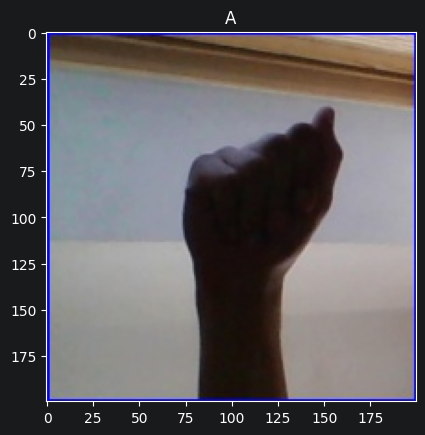

In [82]:
from PIL import Image
import matplotlib.pyplot as plt

# Wähl dir eine Klasse aus und bau den Pfad zu einem Bild zusammen
class_name = "A"  # <- z.B. ein Buchstabe
class_path = os.path.join(data_dir, class_name)
images = os.listdir(class_path)

# Lade das erste Bild
img = Image.open(os.path.join(class_path, images[0]))

plt.imshow(img)
plt.title(class_name)
plt.show()

In [83]:
for class_name in classes:
    class_path = os.path.join(data_dir, class_name)
    num_images = len(os.listdir(class_path))
    print(f"{class_name}: {num_images} Bilder")

A: 3000 Bilder
B: 3000 Bilder
C: 3000 Bilder
D: 3000 Bilder
E: 3000 Bilder
F: 3000 Bilder
G: 3000 Bilder
H: 3000 Bilder
I: 3000 Bilder
J: 3000 Bilder
K: 3000 Bilder
L: 3000 Bilder
M: 3000 Bilder
N: 3000 Bilder
O: 3000 Bilder
P: 3000 Bilder
Q: 3000 Bilder
R: 3000 Bilder
S: 3000 Bilder
T: 3000 Bilder
U: 3000 Bilder
V: 3000 Bilder
W: 3000 Bilder
X: 3000 Bilder
Y: 3000 Bilder
Z: 3000 Bilder
del: 3000 Bilder
nothing: 3000 Bilder
space: 3000 Bilder


In [84]:
img = Image.open(os.path.join(data_dir, classes[0], images[0]))
print(img.size)

(200, 200)


In [85]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)), # skaliert auf die erwartete Größe von ResNet18
    transforms.ToTensor() #skaliert den Wert eines Pixels von 0-255 auf 0-1
])

dataset = datasets.ImageFolder(root=data_dir, transform=transform)
print(f"Gesamtbilder: {len(dataset)}")
print(f"Klassen: {dataset.classes}")

Gesamtbilder: 87000
Klassen: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


In [98]:
from torch.utils.data import random_split
train_dataset, val_dataset = random_split(dataset, [0.8, 0.2])
print(f"Trainingsbilder: {len(training_size)}")
print(f"Validationsbilder: {len(validation_size)}")

Trainingsbilder: 69600
Validationsbilder: 17400


In [99]:
from torch.utils.data import DataLoader
trainloader = DataLoader(training_size, batch_size=32, shuffle=True)
validationloader = DataLoader(validation_size, batch_size=32, shuffle=True)

In [100]:
from torchvision import models
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
model1= models.resnet18(weights="DEFAULT")
print(model1)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [101]:
from torch import nn
model1.fc = nn.Linear(in_features=512, out_features=29) # letzte Schicht auf die 29 Klassen skalieren
print(model1.fc)

torch.device("mps")
model1 = model1.to("mps")
print(model1)

Linear(in_features=512, out_features=29, bias=True)
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_run

In [102]:
from torch import optim

criterion = nn.CrossEntropyLoss() # Loss Funktion
optimizer = optim.Adam(model1.parameters(), lr=0.001) # Optimizer


In [103]:
for epoch in range(10):
    model1.train() # Setzt das Modell in den Trainingsmodus
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to("mps"), labels.to("mps") # Daten auf die GPU verschieben
        optimizer.zero_grad() # Gradienten zurücksetzen
        outputs = model1(images) # Vorwärtsdurchlauf
        loss = criterion(outputs, labels) # Verlust berechnen
        loss.backward() # Rückwärtsdurchlauf
        optimizer.step() # Gewichte aktualisieren
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader)}")

KeyboardInterrupt: 

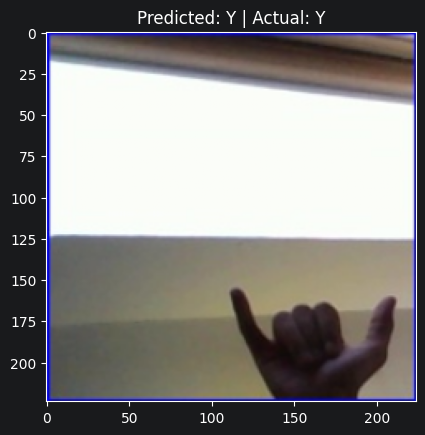

In [104]:
model1.eval()

# Ein Bild aus dem Validation Set nehmen
img, label = validation_size[0]
img_input = img.unsqueeze(0).to("mps")  # Batch-Dimension hinzufügen

with torch.no_grad():
    output = model1(img_input)
    _, predicted = torch.max(output, 1)

# Klasse anzeigen
class_names = dataset.classes
plt.imshow(img.permute(1, 2, 0))  # Tensor zurück zu Bild-Format
plt.title(f"Predicted: {class_names[predicted.item()]} | Actual: {class_names[label]}")
plt.show()